In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image


# Cached version
class UnlabeledTIFFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(('tif', 'tiff'))
        ]

        self.data = []
        for img_path in self.image_paths:
            try:
                image = tiff.imread(img_path).astype(np.float32)
                image = image * 240
                image[image > 254] = 254
                if image.ndim == 3:
                    image = image[0]
                image = image / 255

                if self.transform:
                    image = self.transform(image)
                image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)
                self.data.append(image)
            except Exception as e:
                print(f"Warning: Skipping unreadable image {img_path} - {e}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]

        # Ensure it's a torch tensor
        if not isinstance(image, torch.Tensor):
            image = torch.tensor(image, dtype=torch.float32)

        # # Ensure shape is [1, H, W]
        # if image.ndim == 2:  # [H, W]
        #     image = image.unsqueeze(0)
        # elif image.ndim == 3 and image.shape[0] != 1:
        #     # If image is [C, H, W] but C != 1, take the first channel
        #     image = image[0].unsqueeze(0)

        return image, 0  # Dummy label



# Step 1: Define a standard Autoencoder (AE)
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


class AE(torch.nn.Module):
    def __init__(self, latent_dim=8):
        super(AE, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 32 -> 16
            torch.nn.LeakyReLU(0.01),
            torch.nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 16 -> 8
            torch.nn.LeakyReLU(0.01),
            torch.nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 8 -> 4
            torch.nn.LeakyReLU(0.01),
            torch.nn.Flatten()
        )
        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(128 * 4 * 4, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Linear(1024, latent_dim)
        )

        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Linear(1024, 128 * 4 * 4)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 4 -> 8
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),   # 16 -> 32
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z).view(-1, 128, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

def plot_reconstruction_progress(model, dataloader, device, epoch):
    """Plot original vs reconstructed images during training"""
    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            recon, _ = model(x)
            break  # only one batch

    x = x.cpu()
    recon = recon.cpu()

    print(f"Input stats — min: {x.min().item():.4f}, max: {x.max().item():.4f}, mean: {x.mean().item():.4f}, std: {x.std().item():.4f}")
    print(f"Reconstruction stats — min: {recon.min().item():.4f}, max: {recon.max().item():.4f}, mean: {recon.mean().item():.4f}, std: {recon.std().item():.4f}")

    n = min(8, x.size(0))
    fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
    plt.suptitle(f"Reconstruction at Epoch {epoch}")
    plt.tight_layout()
    plt.show()



# Step 2: Train Autoencoder and Extract Latent Representations
def train_ae(model, train_loader, val_loader, epochs=500, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, _ = model(x)
            loss = loss_fn(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                loss = loss_fn(recon, x)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if (epoch + 1) % 50 == 0:
            plot_reconstruction_progress(model, val_loader, device, epoch + 1)
            

    # Plot training and validation loss
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()

    return model


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([    
    transforms.ToTensor()
])


ae = torch.load('../results/pax_ch1_ps32_ctrl_Y_grid_00_bestmodel_1000epoch.pt', map_location=device, weights_only=False)
ae.eval()


train_pax_ch1_ctrl_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521'

train_pax_ch1_y_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532'


pax_ch2_ctrl_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch2_major/ctrl_ch2_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1525'


pax_ch0_ctrl_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch0_major/ctrl_ch0_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1518'

pPax_ch0_ctrl_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/ctrl_ch0_major/ctrl_ch0_patches_gridonly_pslocation00/tiff_patches32_65p_20250911_1113'


pPax_ch1_ctrl_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/ctrl_ch1_major/ctrl_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250911_1115'


pPax_ch0_y_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250911_1116'

pPax_ch1_y_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/y_ch0_major/y_ch0_patches_gridonly_pslocation00/tiff_patches32_65p_20250911_1118'

train_pax_ch1_ctrl_loader = DataLoader(UnlabeledTIFFDataset(root_dir=train_pax_ch1_ctrl_dir, transform=transform), batch_size=128, shuffle=False)
train_pax_ch1_y_loader = DataLoader(UnlabeledTIFFDataset(root_dir=train_pax_ch1_y_dir, transform=transform), batch_size=128, shuffle=False)

pax_ch2_ctrl_loader = DataLoader(UnlabeledTIFFDataset(root_dir=pax_ch2_ctrl_dir, transform=transform), batch_size=128, shuffle=False)
pax_ch0_ctrl_loader = DataLoader(UnlabeledTIFFDataset(root_dir=pax_ch0_ctrl_dir, transform=transform), batch_size=128, shuffle=False)


pPax_ch0_ctrl_loader = DataLoader(UnlabeledTIFFDataset(root_dir=pPax_ch0_ctrl_dir, transform=transform), batch_size=128, shuffle=False)
pPax_ch1_ctrl_loader = DataLoader(UnlabeledTIFFDataset(root_dir=pPax_ch1_ctrl_dir, transform=transform), batch_size=128, shuffle=False)

pPax_ch0_y_loader = DataLoader(UnlabeledTIFFDataset(root_dir=pPax_ch0_y_dir, transform=transform), batch_size=128, shuffle=False)
pPax_ch1_y_loader = DataLoader(UnlabeledTIFFDataset(root_dir=pPax_ch1_y_dir, transform=transform), batch_size=128, shuffle=False)




/tmp/ipykernel_2469622/63780102.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


In [53]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from umap import UMAP
import joblib

# Step 3: Cluster in Latent Space

def cluster_latents(model, dataloader, num_clusters=6):
    model.eval()
    latents = []
    images = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)
    print(images.shape)

    # load the model
    kmeans = joblib.load("..results/kmeans_model_pax_ch1_BN_ps32_ctrl_Y_gridwhole_00_20000epoch.pkl")
    labels = kmeans.predict(latents)

    return latents, labels, images

# Step 4: Visualize Clusters with t-SNE and Reconstructed Images

def visualize_clusters(latents, labels, images, model):

    # load model
    umap = joblib.load("../results/umap_model_pax_ch1_BN_ps32_ctrl_Y_gridwhole_00_20000epoch.pkl")
    latents_2d = umap.transform(latents)

    plt.figure(figsize=(5, 3.5))
    plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("2D Visualization of Latent Space using UMAP")
    plt.show()

    selected_images = []
    selected_labels = set()
    for i, label in enumerate(labels):
        if label not in selected_labels:
            selected_labels.add(label)
            selected_images.append(images[i])
        if len(selected_labels) == 4:
            break

    selected_images = torch.stack(selected_images).to(device)
    reconstructed, _ = model(selected_images)

    fig, axes = plt.subplots(2, len(selected_images), figsize=(15, 5))
    for i in range(len(selected_images)):
        axes[0, i].imshow(selected_images[i].squeeze().cpu(), cmap='gray', vmax=1.0, vmin=0)
        axes[1, i].imshow(reconstructed[i].squeeze().cpu().detach(), cmap='gray', vmax=1.0, vmin=0)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    plt.show()
    return latents_2d


In [4]:
def data_to_latents(model, dataloader):
    model.eval()
    latents = []
    images = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            print(x.shape)
            _, z = model(x)
            latents.append(z.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)
    print(images.shape)

    return latents, images

In [5]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# Step 5: Show multiple decoded images per cluster

def cluster_and_display_images(latents, labels, images, model, num_samples_per_cluster=10):
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels)*2, num_samples_per_cluster, figsize=(num_samples_per_cluster*1.5, len(unique_labels)*2))

    for cluster_idx, cluster_label in enumerate(unique_labels):
        cluster_indices = np.where(labels == cluster_label)[0][:num_samples_per_cluster]
        cluster_images = images[cluster_indices].to(device)
        recon_images, _ = model(cluster_images)

        for i in range(num_samples_per_cluster):
            axes[2 * cluster_idx, i].imshow(cluster_images[i].squeeze().cpu(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx + 1, i].imshow(recon_images[i].squeeze().cpu().detach(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx, i].axis('off')
            axes[2 * cluster_idx + 1, i].axis('off')

    plt.tight_layout()
    plt.show()


In [6]:
def cluster_2Dplot(latents, ind1,ind2,labels):
    plt.figure(figsize=(8, 6))
    plt.scatter(latents[:, ind1], latents[:, ind2], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("F1")
    plt.ylabel("F2")
    plt.title("2D Visualization of Latent Space F0-F1")
    plt.show()
    

In [7]:
def cluster_3Dplot(latents, ind1,ind2,ind3, labels):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(latents[:, ind1], latents[:, ind2],latents[:, ind3], c=labels, cmap='tab10',s=1)
    plt.xlabel('F'+str(ind1))
    plt.ylabel('F'+str(ind2))
    plt.ylabel('F'+str(ind3))
    plt.title('3D Visualization of Latent Space F' +str(ind1)+'-'+str(ind2)+'-'+str(ind3))
    plt.show()
    

In [54]:
def latent_to_umap(latents):

    # load model
    umap = joblib.load("../results/umap_model_pax_ch1_BN_ps32_ctrl_Y_gridwhole_00_20000epoch.pkl")
    umap_latents_2d = umap.transform(latents)

    return umap_latents_2d


In [55]:
def kmeans_latents(latents):
    # load the model
    kmeans = joblib.load("../results/kmeans_model_pax_ch1_BN_ps32_ctrl_Y_gridwhole_00_20000epoch.pkl")
    labels = kmeans.predict(latents)

    return labels 

In [15]:
dir1 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521'
dir2 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532'

ds1 = UnlabeledTIFFDataset(root_dir=dir1, transform=transform)
ds2 = UnlabeledTIFFDataset(root_dir=dir2, transform=transform)
from torch.utils.data import ConcatDataset
train_dataset = ConcatDataset([ds1, ds2])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)


/tmp/ipykernel_2469622/63780102.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


In [56]:
train_latents, train_images = data_to_latents(ae, train_loader)


torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([12

In [61]:
train_umap_latents_2d = latent_to_umap(train_latents)
train_labels = kmeans_latents(train_latents)

In [62]:
train_latents.shape

(6586, 8)

In [63]:
train_umap_latents_2d.shape

(6586, 2)

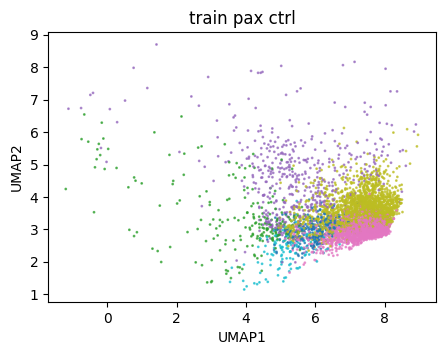

In [64]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_umap_latents_2d[:, 0], train_umap_latents_2d[:, 1], c=train_labels, cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax ctrl")
plt.show()

In [65]:
train_pax_ch1_ctrl_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, train_pax_ch1_ctrl_loader)
train_pax_ch1_y_latents, train_pax_ch1_y_images = data_to_latents(ae, train_pax_ch1_y_loader)

pax_ch2_ctrl_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, pax_ch2_ctrl_loader)
pax_ch0_ctrl_latents, train_pax_ch1_y_images = data_to_latents(ae, pax_ch0_ctrl_loader)

pPax_ch0_ctrl_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, pPax_ch0_ctrl_loader)
pPax_ch1_ctrl_latents, train_pax_ch1_y_images = data_to_latents(ae, pPax_ch1_ctrl_loader)

pPax_ch0_y_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, pPax_ch0_y_loader)
pPax_ch1_y_latents, train_pax_ch1_y_images = data_to_latents(ae, pPax_ch1_y_loader)



torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([128, 1, 32, 32])
torch.Size([109, 1, 32, 32])
torch.Size([4205, 1, 32, 32])
torch.Size([1

In [66]:

train_pax_ch1_ctrl_umap_latents_2d = latent_to_umap(train_pax_ch1_ctrl_latents)
train_pax_ch1_yy_umap_latents_2d = latent_to_umap(train_pax_ch1_y_latents)

pax_ch2_ctrl_umap_latents_2d = latent_to_umap(pax_ch2_ctrl_latents)
pax_ch0_ctrly_umap_latents_2d = latent_to_umap(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_umap_latents_2d = latent_to_umap(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_umap_latents_2d = latent_to_umap(pPax_ch1_ctrl_latents)

pPax_ch0_y_umap_latents_2d = latent_to_umap(pPax_ch0_y_latents)
pPax_ch1_y_umap_latents_2d = latent_to_umap(pPax_ch1_y_latents)

In [67]:
train_pax_ch1_ctrl_labels = kmeans_latents(train_pax_ch1_ctrl_latents)
train_pax_ch1_y_labels = kmeans_latents(train_pax_ch1_y_latents)

pax_ch2_ctrl_labels = kmeans_latents(pax_ch2_ctrl_latents)
pax_ch0_ctrly_labels = kmeans_latents(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_labels = kmeans_latents(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_labels = kmeans_latents(pPax_ch1_ctrl_latents)

pPax_ch0_y_labels = kmeans_latents(pPax_ch0_y_latents)
pPax_ch1_y_labels = kmeans_latents(pPax_ch1_y_latents)


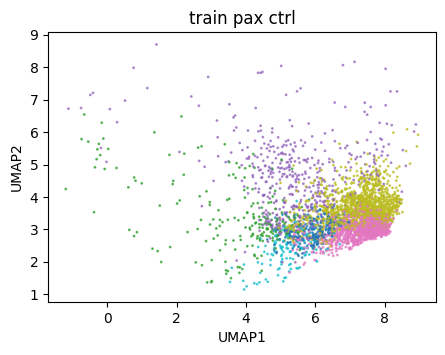

In [68]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c=train_pax_ch1_ctrl_labels, cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax ctrl")
plt.show()


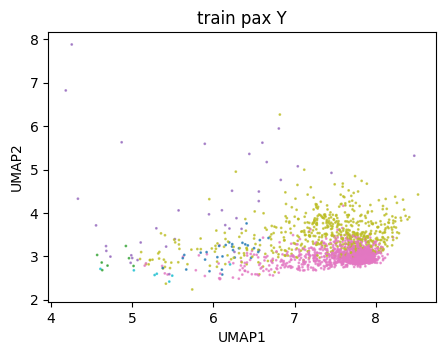

In [69]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c=train_pax_ch1_y_labels, cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax Y")
plt.show()

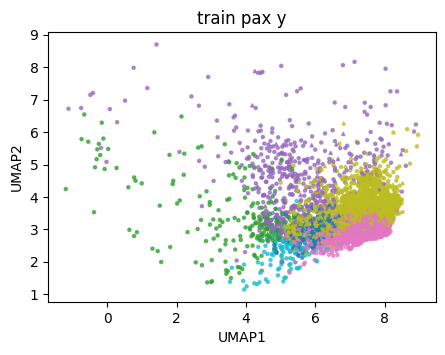

In [70]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c=train_pax_ch1_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c=train_pax_ch1_y_labels, cmap='tab10', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

In [71]:
pax_ch2_ctrl_labels = kmeans_latents(pax_ch2_ctrl_latents)
pax_ch0_ctrly_labels = kmeans_latents(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_labels = kmeans_latents(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_labels = kmeans_latents(pPax_ch1_ctrl_latents)

pPax_ch0_y_labels = kmeans_latents(pPax_ch0_y_latents)
pPax_ch1_y_labels = kmeans_latents(pPax_ch1_y_latents)


In [72]:
train_pax_ch1_ctrl_umap_latents_2d = latent_to_umap(train_pax_ch1_ctrl_latents)
train_pax_ch1_yy_umap_latents_2d = latent_to_umap(train_pax_ch1_y_latents)

pax_ch2_ctrl_umap_latents_2d = latent_to_umap(pax_ch2_ctrl_latents)
pax_ch0_ctrly_umap_latents_2d = latent_to_umap(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_umap_latents_2d = latent_to_umap(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_umap_latents_2d = latent_to_umap(pPax_ch1_ctrl_latents)

pPax_ch0_y_umap_latents_2d = latent_to_umap(pPax_ch0_y_latents)
pPax_ch1_y_umap_latents_2d = latent_to_umap(pPax_ch1_y_latents)

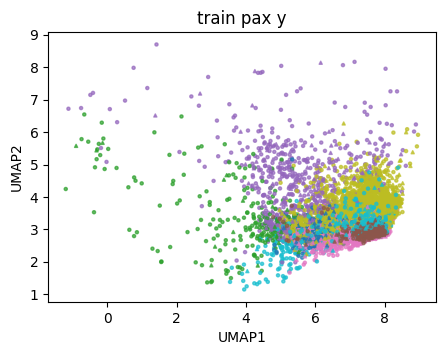

In [73]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c=train_pax_ch1_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c=train_pax_ch1_y_labels, cmap='tab10', alpha=0.7, s=5, marker='^')
plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c=pax_ch2_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c=pax_ch0_ctrly_labels, cmap='tab10', alpha=0.7, s=5, marker='^')
plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c=pPax_ch0_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c=pPax_ch1_ctrly_labels, cmap='tab10', alpha=0.7, s=5, marker='^')
plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c=pPax_ch0_y_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c=pPax_ch1_y_labels, cmap='tab10', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

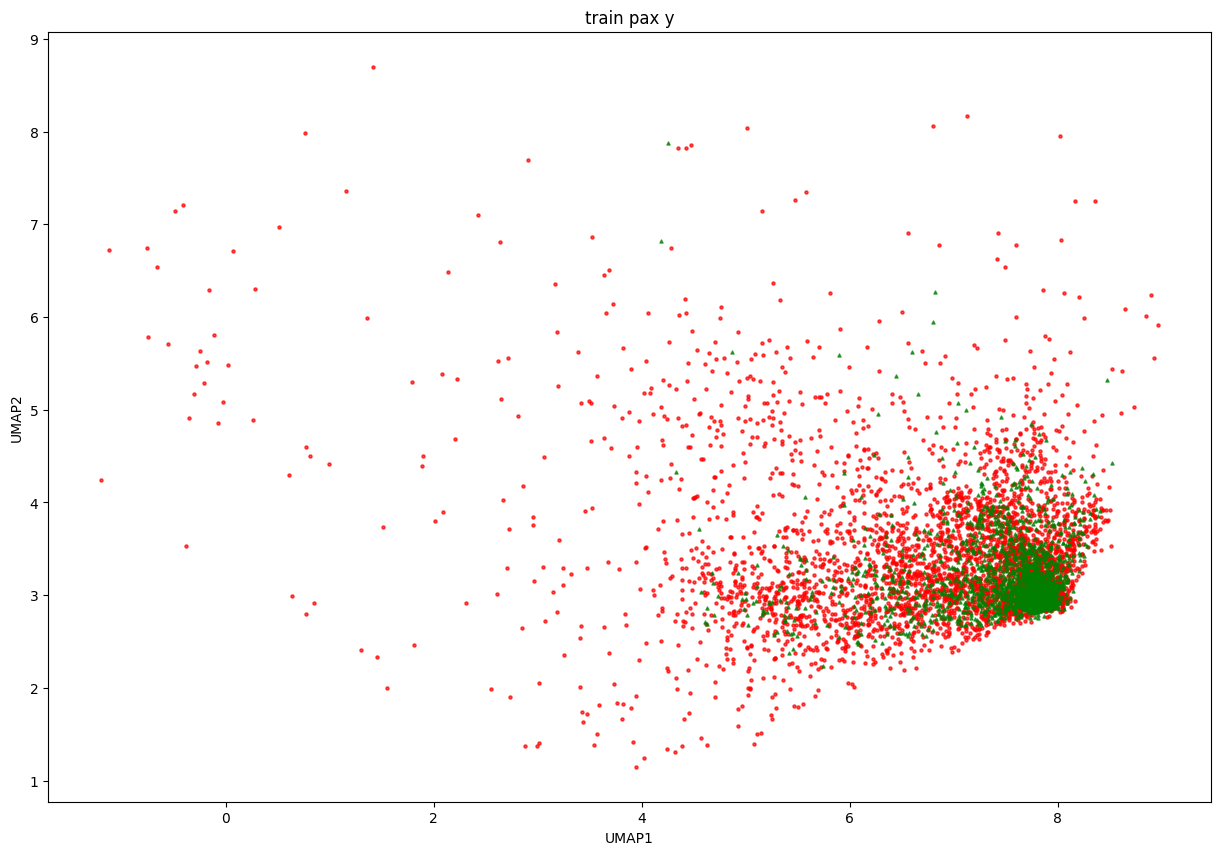

In [74]:
plt.figure(figsize=(15, 10))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c='red', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c='green', alpha=0.7, s=5, marker='^')
# plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5)
# plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c='magenta', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c='orange', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c='pink', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c='black', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

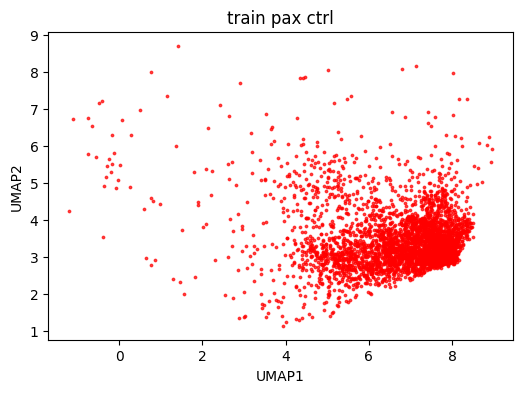

In [75]:
plt.figure(figsize=(6, 4))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c='red', alpha=0.7, s=3)
# plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c='green', alpha=0.7, s=5, marker='^')
# plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5)
# plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c='magenta', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c='orange', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c='pink', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c='black', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax ctrl")
plt.show()

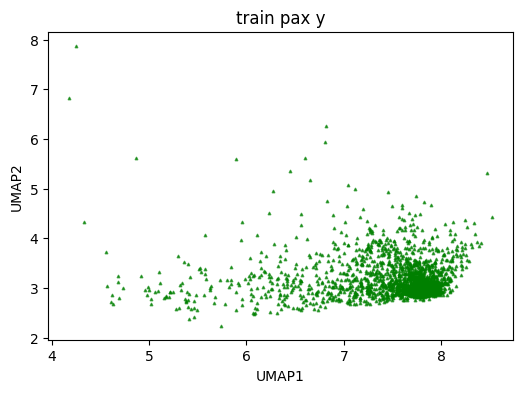

In [76]:
plt.figure(figsize=(6, 4))
# plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c='red', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c='green', alpha=0.7, s=3, marker='^')
# plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5)
# plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c='magenta', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c='orange', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c='pink', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c='black', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

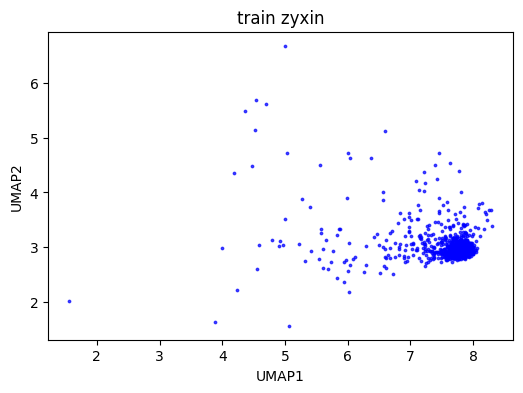

In [77]:
plt.figure(figsize=(6, 4))
# plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c='red', alpha=0.7, s=5)
# plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c='green', alpha=0.7, s=5, marker='^')
plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=3)
# plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c='magenta', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c='orange', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c='pink', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c='black', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train zyxin")
plt.show()

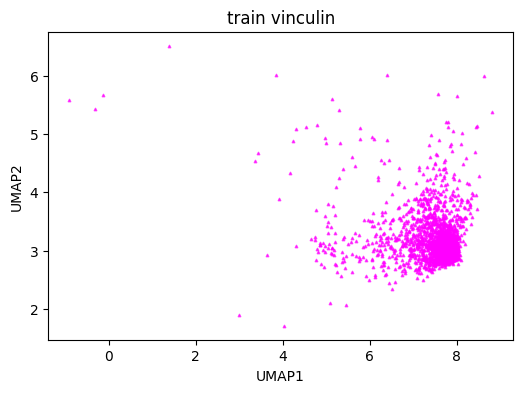

In [78]:
plt.figure(figsize=(6, 4))
# plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c='red', alpha=0.7, s=5)
# plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c='green', alpha=0.7, s=5, marker='^')
# plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5)
plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c='magenta', alpha=0.7, s=3, marker='^')
# plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c='orange', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c='pink', alpha=0.7, s=5, marker='^')
# plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c='black', alpha=0.7, s=5)
# plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train vinculin")
plt.show()

In [79]:
cluster_3Dplot(latents, 0,1,2,labels)

NameError: name 'latents' is not defined

In [ ]:
cluster_3Dplot(latents, 3,4,5,labels)

In [ ]:
latents_2d = visualize_clusters(latents, labels, images, ae)


In [ ]:
cluster_and_display_images(latents, labels, images, ae, num_samples_per_cluster=10)
